<a href="https://colab.research.google.com/github/blankqspace/homework_compling_course/blob/main/word2vec_homework_Artamonova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Домашку будет легче делать в колабе (убедитесь, что у вас runtype с gpu).

# Задание 1 (3 балла)

Обучите word2vec модели с негативным семплированием (cbow и skip-gram) аналогично тому, как это было сделано в семинаре. Вам нужно изменить следующие пункты:
1) добавьте лемматизацию в предобработку (любым способом)  
2) измените размер окна в большую или меньшую сторону
3) измените размерность итоговых векторов

Выберете несколько не похожих по смыслу слов (не таких как в семинаре), и протестируйте полученные эмбединги (найдите ближайшие слова и оцените качество, как в семинаре).
Постарайтесь обучать модели как можно дольше и на как можно большем количестве данных. (Но если у вас мало времени или ресурсов, то допустимо взять поменьше данных и поставить меньше эпох)

In [4]:
!pip install razdel pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 107.7 MB/s eta 0:00:00


In [6]:
import re
from razdel import tokenize
from pymorphy3 import MorphAnalyzer
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, TensorDataset
from string import punctuation
from collections import Counter

In [14]:
wiki = open('wiki_data.txt').read().split('\n')

In [15]:
morph = MorphAnalyzer()

def preprocess(text):
    text_clean = re.sub('#+', ' ', text.lower())
    tokens = list(tokenize(text_clean))
    lemmas = []

    for token in tokens:
        word = token.text.strip(punctuation)
        if word:
            lemma = morph.parse(word)[0].normal_form
            lemmas.append(lemma)

    return lemmas



In [23]:
vocab = Counter()
for text in wiki:
    vocab.update(preprocess(text))

In [24]:
filtered_vocab = set()

for word in vocab:
    if vocab[word] > 30:
        filtered_vocab.add(word)

len(filtered_vocab)

12701

In [25]:
word2id = {'PAD':0}

for word in filtered_vocab:
    word2id[word] = len(word2id)

In [26]:
id2word = {i:word for word, i in word2id.items()}

In [27]:
sentences = []

for text in wiki:
    tokens = preprocess(text)
    if not tokens:
        continue
    ids = [word2id[token] for token in tokens if token in word2id]
    sentences.append(ids)

In [28]:
# skip gram
X = []
y = []

window = 5
for sent in sentences[:1000]:
    for i in range(len(sent)-1):
        word = sent[i] # target
        context = sent[max(0, i-window):i] + sent[i+1:i+window]  # context (слова до и после целевого)
        # в начале и в конце окно будет неполным, но это не страшно

        for context_word in context:
            X.append(word)
            y.append(context_word)

In [29]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.05)

In [17]:
class SkipGramSoftmax(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        """
        x: LongTensor (batch,)
        """
        e = self.emb(x)           # (batch, emb_dim)
        logits = self.fc(e)       # (batch, vocab_size)
        return logits

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch version:", torch.__version__)

Using device: cuda
Torch version: 2.9.0+cu126


In [30]:
vocab_size = len(word2id)
emb_dim = 100

model = SkipGramSoftmax(vocab_size, emb_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [31]:
X_train_t = torch.LongTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_valid_t = torch.LongTensor(X_valid)
y_valid_t = torch.LongTensor(y_valid)

train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)

train_loader = DataLoader(train_ds, batch_size=1000, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=1000)

In [22]:
num_epochs = 20
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            # нет backward степа!
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(valid_ds)
    valid_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.4f}, val loss: {val_loss:.4f}")

Epoch 1/20 - train loss: 7.7528, val loss: 7.2343
Epoch 2/20 - train loss: 7.0881, val loss: 7.1415
Epoch 3/20 - train loss: 6.9559, val loss: 7.1002
Epoch 4/20 - train loss: 6.8663, val loss: 7.0723
Epoch 5/20 - train loss: 6.7972, val loss: 7.0531
Epoch 6/20 - train loss: 6.7416, val loss: 7.0387
Epoch 7/20 - train loss: 6.6951, val loss: 7.0260
Epoch 8/20 - train loss: 6.6554, val loss: 7.0174
Epoch 9/20 - train loss: 6.6208, val loss: 7.0108
Epoch 10/20 - train loss: 6.5902, val loss: 7.0063
Epoch 11/20 - train loss: 6.5628, val loss: 7.0037
Epoch 12/20 - train loss: 6.5382, val loss: 7.0006
Epoch 13/20 - train loss: 6.5158, val loss: 7.0001
Epoch 14/20 - train loss: 6.4956, val loss: 7.0003
Epoch 15/20 - train loss: 6.4767, val loss: 7.0005
Epoch 16/20 - train loss: 6.4595, val loss: 7.0025
Epoch 17/20 - train loss: 6.4436, val loss: 7.0052
Epoch 18/20 - train loss: 6.4287, val loss: 7.0082
Epoch 19/20 - train loss: 6.4148, val loss: 7.0110
Epoch 20/20 - train loss: 6.4019, val lo

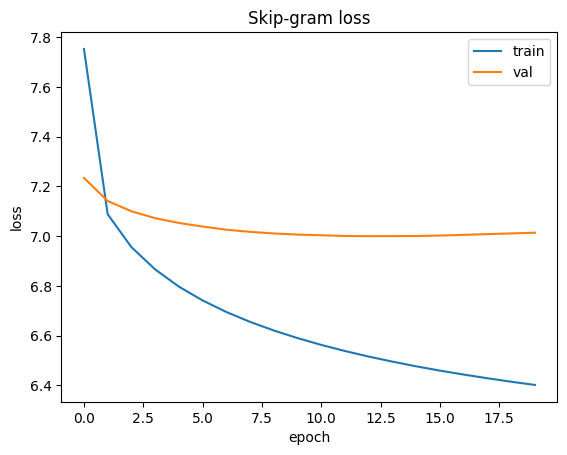

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Skip-gram loss')
plt.legend()
plt.show()

In [24]:
import numpy as np
embeddings_1 = model.emb.weight.detach().cpu().numpy()               # (vocab_size, emb_dim)
embeddings_2 = model.fc.weight.detach().cpu().numpy()#.T            # (vocab_size, emb_dim)

embeddings = np.mean([embeddings_1, embeddings_2], axis=0)

embeddings.shape

(12702, 100)

In [43]:
from sklearn.metrics.pairwise import cosine_distances

def most_similar(word, embeddings):
    similar = [id2word[i] for i in
               cosine_distances(embeddings[word2id[word]].reshape(1, -1), embeddings).argsort()[0][:10]]
    return similar

In [26]:
most_similar("дом", embeddings)


['дом',
 'застроить',
 'жилой',
 'зал',
 'товарищество',
 'комната',
 'дача',
 'основатель',
 'контора',
 'окружать']

In [28]:
most_similar("человек", embeddings)

['человек',
 'население',
 '2001',
 'прирост',
 'они',
 'тысяча',
 '225',
 'почта',
 'составить',
 'ж']

cbow


In [29]:
# cbow
import numpy as np

def pad_sequences(sequences, maxlen, padding='post', value=0):
    """
    sequences: list of lists (разной длины)
    возвращает np.array shape (len(sequences), maxlen)
    """
    res = np.full((len(sequences), maxlen), value, dtype='int64')
    for i, seq in enumerate(sequences):
        if not seq:
            continue
        if len(seq) >= maxlen:
            if padding == 'post':
                res[i] = np.array(seq[:maxlen])
            else:
                res[i] = np.array(seq[-maxlen:])
        else:
            if padding == 'post':
                res[i, :len(seq)] = np.array(seq)
            else:
                res[i, -len(seq):] = np.array(seq)
    return res


In [30]:
X = []
y = []

window = 5
for sent in sentences[:10000]:
    for i in range(len(sent)-1):
        word = sent[i]
        context = sent[max(0, i-window):i] + sent[i+1:i+window]
        X.append(context)
        y.append(word)

X = pad_sequences(X, maxlen=10, padding='post', value=0)
y = np.array(y, dtype='int64')

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.05)

In [31]:
class CBOWSoftmax(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        """
        x: LongTensor (batch, window_size)
        """
        e = self.emb(x)              # (batch, window, emb_dim)
        context_vec = e.sum(dim=1)   # (batch, emb_dim)
        logits = self.fc(context_vec)
        return logits

In [32]:
vocab_size = len(word2id)
emb_dim = 100

model = CBOWSoftmax(vocab_size, emb_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [33]:
X_train_t = torch.LongTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_valid_t = torch.LongTensor(X_valid)
y_valid_t = torch.LongTensor(y_valid)

train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)

train_loader = DataLoader(train_ds, batch_size=1000, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=1000)

In [34]:
num_epochs = 20
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(valid_ds)
    valid_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.4f}, val loss: {val_loss:.4f}")

Epoch 1/20 - train loss: 7.0869, val loss: 6.5166
Epoch 2/20 - train loss: 6.1931, val loss: 6.2602
Epoch 3/20 - train loss: 5.9325, val loss: 6.1573
Epoch 4/20 - train loss: 5.7813, val loss: 6.0951
Epoch 5/20 - train loss: 5.6710, val loss: 6.0494
Epoch 6/20 - train loss: 5.5828, val loss: 6.0159
Epoch 7/20 - train loss: 5.5078, val loss: 5.9870
Epoch 8/20 - train loss: 5.4431, val loss: 5.9656
Epoch 9/20 - train loss: 5.3857, val loss: 5.9496
Epoch 10/20 - train loss: 5.3348, val loss: 5.9332
Epoch 11/20 - train loss: 5.2885, val loss: 5.9250
Epoch 12/20 - train loss: 5.2464, val loss: 5.9175
Epoch 13/20 - train loss: 5.2076, val loss: 5.9115
Epoch 14/20 - train loss: 5.1724, val loss: 5.9063
Epoch 15/20 - train loss: 5.1394, val loss: 5.9041
Epoch 16/20 - train loss: 5.1090, val loss: 5.9016
Epoch 17/20 - train loss: 5.0803, val loss: 5.9021
Epoch 18/20 - train loss: 5.0536, val loss: 5.9057
Epoch 19/20 - train loss: 5.0287, val loss: 5.9059
Epoch 20/20 - train loss: 5.0051, val lo

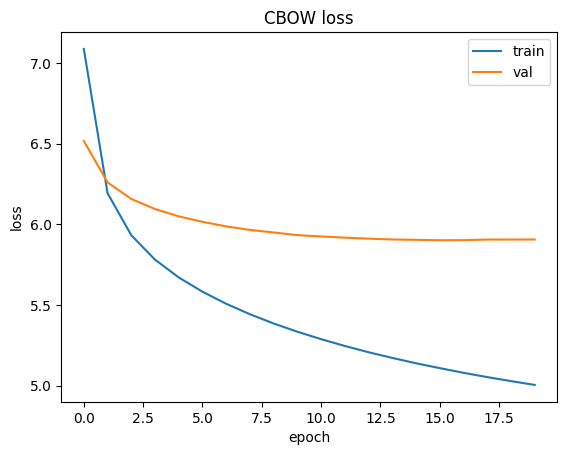

In [35]:
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('CBOW loss')
plt.legend()
plt.show()

negative smapling: cbow

In [36]:
vocab_size = len(id2word)

In [37]:
def gen_batches_cbow(sentences, window=5, batch_size=1000):
    left_context_length = (window/2).__ceil__()
    right_context_length = window // 2

    while True:
        X_target = []
        X_context = []
        y = []

        for sent in sentences:
            for i in range(len(sent)-1):
                word = sent[i]
                context = sent[max(0, i-left_context_length):i] + sent[i+1:i+right_context_length]

                X_target.append(word)
                X_context.append(context)
                y.append(1)

                X_target.append(np.random.randint(vocab_size))
                X_context.append(context)
                y.append(0)

                if len(X_target) >= batch_size:
                    X_target_arr = np.array(X_target, dtype='int64')
                    X_context_arr = pad_sequences(X_context, maxlen=window, padding='post', value=0)
                    y_arr = np.array(y, dtype='float32')
                    yield (X_target_arr, X_context_arr), y_arr
                    X_target, X_context, y = [], [], []

In [38]:
class CBOWNegSampling(nn.Module):
    def __init__(self, vocab_size, emb_dim, window_size):
        super().__init__()
        self.target_emb = nn.Embedding(vocab_size, emb_dim)
        self.context_emb = nn.Embedding(vocab_size, emb_dim)
        self.window_size = window_size

    def forward(self, target_ids, context_ids):
        """
        target_ids: (batch,)
        context_ids: (batch, window_size)
        """
        t = self.target_emb(target_ids)          # (batch, emb_dim)
        c = self.context_emb(context_ids)        # (batch, window, emb_dim)
        c_sum = c.sum(dim=1)                     # (batch, emb_dim)
        dot = (t * c_sum).sum(dim=1)             # (batch,)
        return dot

In [45]:
# меняем размер эмбеддинга и контекстное окно
emb_dim = 200
window_size = 7

model = CBOWNegSampling(vocab_size, emb_dim, window_size).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_gen = gen_batches_cbow(sentences[:19000], window=window_size, batch_size=1000)
valid_gen = gen_batches_cbow(sentences[19000:], window=window_size, batch_size=1000)

In [46]:
steps_per_epoch = 5000
validation_steps = 30
num_epochs = 10 # тут у меня осталось мало времени на гпу :((((

train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for step in range(steps_per_epoch):
        (X_t, X_c), y = next(train_gen)
        X_t = torch.LongTensor(X_t).to(device)
        X_c = torch.LongTensor(X_c).to(device)
        y_t = torch.FloatTensor(y).to(device)

        optimizer.zero_grad()
        logits = model(X_t, X_c)
        loss = criterion(logits, y_t)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= steps_per_epoch

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for _ in range(validation_steps):
            (X_t, X_c), y = next(valid_gen)
            X_t = torch.LongTensor(X_t).to(device)
            X_c = torch.LongTensor(X_c).to(device)
            y_t = torch.FloatTensor(y).to(device)

            logits = model(X_t, X_c)
            loss = criterion(logits, y_t)
            val_loss += loss.item()

    val_loss /= validation_steps

    train_losses.append(epoch_loss)
    valid_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.4f}, val loss: {val_loss:.4f}")

Epoch 1/10 - train loss: 8.2235, val loss: 6.3084
Epoch 2/10 - train loss: 5.3274, val loss: 4.8377
Epoch 3/10 - train loss: 4.1116, val loss: 4.1589
Epoch 4/10 - train loss: 3.3065, val loss: 3.5131
Epoch 5/10 - train loss: 2.6747, val loss: 3.1173
Epoch 6/10 - train loss: 2.1541, val loss: 3.0309
Epoch 7/10 - train loss: 1.8090, val loss: 2.6142
Epoch 8/10 - train loss: 1.4637, val loss: 2.3198
Epoch 9/10 - train loss: 1.2374, val loss: 1.8628
Epoch 10/10 - train loss: 1.0298, val loss: 2.0991


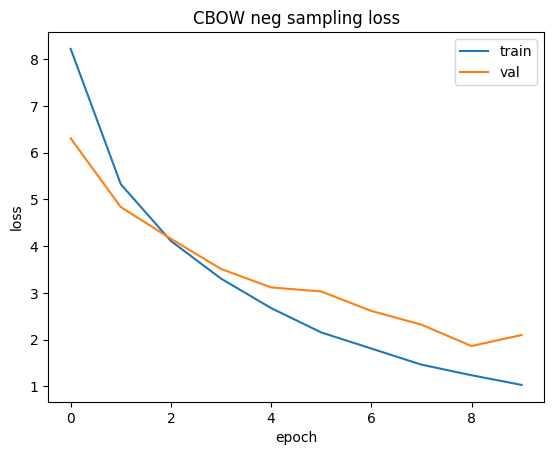

In [47]:
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('CBOW neg sampling loss')
plt.legend()
plt.show()

In [48]:
embeddings = model.context_emb.weight.detach().cpu().numpy()

In [49]:
most_similar('дом', embeddings) # тут вообще мимо...

['дом',
 'здесь',
 'василиевич',
 'тара',
 'пролёт',
 'удмуртский',
 'вечерний',
 'приходить',
 'воронеж',
 'перекрытие']

In [50]:
most_similar('животное', embeddings) # тут явно какая-то проблема с параметрами

['животное',
 'описать',
 'лена',
 'характеризовать',
 'оккупировать',
 'удобрение',
 'порода',
 'цветение',
 'предмет',
 'конрад']

negative sampling: skipgram

In [32]:
# sentences: список списков id-шников слов
# neg_samples: число негативных примеров на 1 позитивный
def gen_batches_skipgram(sentences, window=7, batch_size=1000, neg_samples=1):
    left = (window / 2).__ceil__()
    right = window // 2

    while True:
        X_t = []
        X_c = []
        y = []

        for sent in sentences:
            for i in range(len(sent)):
                center = sent[i]

                # контекстные слова
                context_words = (
                    sent[max(0, i - left):i] +
                    sent[i + 1:i + 1 + right]
                )

                for ctx in context_words:
                    # позитивная пара
                    X_t.append(center)
                    X_c.append(ctx)
                    y.append(1)

                    # негативные пары
                    for _ in range(neg_samples):
                        neg = np.random.randint(vocab_size)
                        X_t.append(center)
                        X_c.append(neg)
                        y.append(0)

                    if len(X_t) >= batch_size:
                        X_t_arr = np.array(X_t, dtype="int64")
                        X_c_arr = np.array(X_c, dtype="int64")
                        y_arr = np.array(y, dtype="float32")
                        yield (X_t_arr, X_c_arr), y_arr
                        X_t, X_c, y = [], [], []


In [33]:

class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.target_emb = nn.Embedding(vocab_size, emb_dim)
        self.context_emb = nn.Embedding(vocab_size, emb_dim)

    def forward(self, target_ids, context_ids):
        """
        target_ids: (batch,)
        context_ids: (batch,)
        """
        t = self.target_emb(target_ids)     # (batch, emb_dim)
        c = self.context_emb(context_ids)   # (batch, emb_dim)
        dot = (t * c).sum(dim=1)            # (batch,)
        return dot


In [35]:
import numpy as np

In [36]:
emb_dim = 200
model = SkipGramNegSampling(vocab_size, emb_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_gen = gen_batches_skipgram(sentences[:19000], window=7, batch_size=1000)
valid_gen = gen_batches_skipgram(sentences[19000:], window=7, batch_size=1000)

steps_per_epoch = 5000
validation_steps = 40
num_epochs = 10

train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for _ in range(steps_per_epoch):
        (X_t, X_c), y = next(train_gen)
        X_t = torch.LongTensor(X_t).to(device)
        X_c = torch.LongTensor(X_c).to(device)
        y = torch.FloatTensor(y).to(device)

        optimizer.zero_grad()
        logits = model(X_t, X_c)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= steps_per_epoch

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for _ in range(validation_steps):
            (X_t, X_c), y = next(valid_gen)
            X_t = torch.LongTensor(X_t).to(device)
            X_c = torch.LongTensor(X_c).to(device)
            y = torch.FloatTensor(y).to(device)

            logits = model(X_t, X_c)
            loss = criterion(logits, y)
            val_loss += loss.item()

    val_loss /= validation_steps

    train_losses.append(epoch_loss)
    valid_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train: {epoch_loss:.4f}  val: {val_loss:.4f}")


Epoch 1/10 - train: 4.2759  val: 3.6581
Epoch 2/10 - train: 2.8685  val: 2.4486
Epoch 3/10 - train: 2.1545  val: 1.8679
Epoch 4/10 - train: 1.7215  val: 1.5906
Epoch 5/10 - train: 1.4283  val: 1.4134
Epoch 6/10 - train: 1.2997  val: 1.1406
Epoch 7/10 - train: 1.1646  val: 1.0950
Epoch 8/10 - train: 1.0424  val: 1.0793
Epoch 9/10 - train: 0.9600  val: 0.9840
Epoch 10/10 - train: 0.8933  val: 0.8717


In [45]:
embeddings = model.context_emb.weight.detach().cpu().numpy()

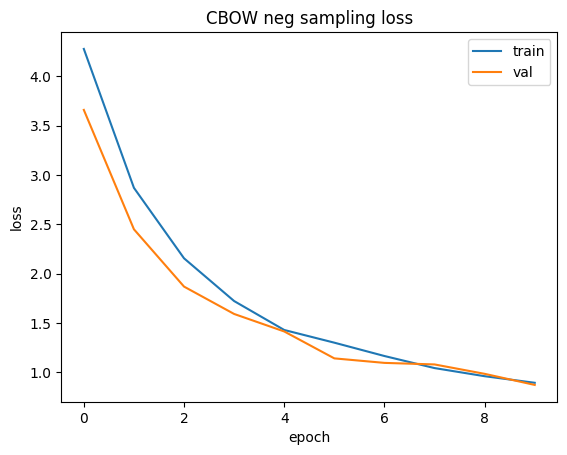

In [41]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('CBOW neg sampling loss')
plt.legend()
plt.show()

In [48]:
most_similar('дом', embeddings)

['дом', 'под', 'год', 'с', '»', 'в', 'который', 'быть', 'они', 'на']

In [47]:
most_similar('животное', embeddings)

['животное',
 'мой',
 'поиск',
 'тренер',
 'установить',
 'род',
 'функция',
 'карта',
 'ленин',
 'сообщать']

# Задание 2 (2 балла)

Обучите 1 word2vec и 1 fastext модель в gensim. В каждой из модели нужно задать все параметры, которые мы разбирали на семинаре. Заданные значения должны отличаться от дефолтных и от тех, что мы использовали на семинаре.

Gensim

In [49]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.1 MB/s eta 0:00:00


In [50]:
import gensim

In [51]:
wiki = open('wiki_data.txt', encoding='utf8').read().split('\n')

In [52]:
texts = [preprocess(text) for text in wiki]

In [54]:
%%time
w2v = gensim.models.Word2Vec(texts,
                             vector_size=200,
                             min_count=50,
                             max_vocab_size=10000,
                             window=3,
                             epochs=10,
                             sg=0,
                             hs=0,
                             sample=2e-4,
                             ns_exponent=0.5,
                             negative=4,
                             cbow_mean=1)

CPU times: user 1min 8s, sys: 453 ms, total: 1min 8s
Wall time: 40.6 s


In [56]:
w2v.wv.most_similar('церковь')

[('храм', 0.7429963946342468),
 ('часовня', 0.7126817107200623),
 ('православный', 0.6795530915260315),
 ('святитель', 0.6626911759376526),
 ('собор', 0.6622725129127502),
 ('богородица', 0.6602477431297302),
 ('епархия', 0.637932300567627),
 ('приход', 0.6108658313751221),
 ('католический', 0.6088313460350037),
 ('священник', 0.5993266105651855)]

In [57]:
w2v.wv.most_similar('дом')

[('квартира', 0.6756843328475952),
 ('гостиница', 0.6546253561973572),
 ('сад', 0.5897265672683716),
 ('комната', 0.5868581533432007),
 ('дворец', 0.5304548740386963),
 ('помещение', 0.5296021103858948),
 ('жилой', 0.5026763081550598),
 ('переулок', 0.48948603868484497),
 ('ресторан', 0.48933541774749756),
 ('здание', 0.477464884519577)]

In [58]:
w2v.wv.most_similar('животное')

[('птица', 0.6923989057540894),
 ('организм', 0.6758029460906982),
 ('пища', 0.6275783181190491),
 ('рыба', 0.6243787407875061),
 ('мясо', 0.6194499731063843),
 ('растение', 0.6006051898002625),
 ('клетка', 0.5896649956703186),
 ('дикий', 0.5823855996131897),
 ('муравей', 0.5809600949287415),
 ('кость', 0.5789778828620911)]

FastText

In [60]:
%%time
ft = gensim.models.FastText(texts, min_n=3, max_n=10)

CPU times: user 7min 16s, sys: 1.31 s, total: 7min 17s
Wall time: 4min 12s


In [61]:
ft.wv.most_similar('церковь')

[('це́рковь', 0.966957688331604),
 ('церква', 0.912669837474823),
 ('монастырь', 0.8621405959129333),
 ('собор', 0.851960301399231),
 ('храм', 0.8497331738471985),
 ('архипастырь', 0.8461348414421082),
 ('морковь', 0.8399745225906372),
 ('пастырь', 0.8045671582221985),
 ('часовня', 0.8009300231933594),
 ('святыня', 0.7907730937004089)]

In [62]:
ft.wv.most_similar('дом')

[('домбе', 0.918454647064209),
 ('эдом', 0.9006620645523071),
 ('узедом', 0.8582524061203003),
 ('чудом', 0.8219081163406372),
 ('ом', 0.7804717421531677),
 ('усадьба', 0.7749089002609253),
 ('домохозяин', 0.7718796133995056),
 ('сад', 0.7654959559440613),
 ('помещица', 0.7615934610366821),
 ('радом', 0.7556853890419006)]

In [63]:
ft.wv.most_similar('животное')

[('живот', 0.9056895971298218),
 ('живо', 0.8936482667922974),
 ('спиртное', 0.8473694324493408),
 ('насекомое', 0.8377169370651245),
 ('живьём', 0.8342645764350891),
 ('пирожное', 0.8322815895080566),
 ('пиво', 0.8272427320480347),
 ('млекопитающее', 0.8224073052406311),
 ('вживую', 0.806083619594574),
 ('пища', 0.8050298094749451)]

# Задание 3 (3 балла)

Используя датасет для классификации (labeled.csv), обучите классификатор на базе эмбеддингов. Оцените качество на отложенной выборке.   
В качестве эмбеддинг модели вы можете использовать одну из моделей обученных в предыдущем задании или использовать одну из предобученных моделей с rusvectores (удостоверьтесь что правильно воспроизводите предобработку в этом случае!)  
Для того, чтобы построить эмбединг целого текста, усредните вектора отдельных слов в один общий вектор.
В качестве алгоритма классификации используйте LogisicticRegression (можете попробовать SGDClassifier, чтобы было побыстрее)  
F1 мера должна быть выше 20%.

In [55]:
import pandas as pd
data = pd.read_csv('labeled.csv')
data

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


In [64]:
data['norm_text'] = data.comment.apply(preprocess)

data

,comment,toxic,norm_text
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,"[верблюд-то, за, что, дебил, бл]"
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,"[хохол, это, отдушина, затюканый, россиянин, м..."
2,Собаке - собачья смерть\n,1.0,"[собака, собачий, смерть]"
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,"[страница, обновить, дебил, это, тоже, не, оск..."
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,"[ты, не, убедить, 6-страничный, пдф, в, тот, ч..."
...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,"[вонючий, совковый, скот, прибежать, и, ныть, ..."
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,"[а, кто, любить, гоблин, тупорылый, что-ли, ил..."
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,"[посмотреть, утомлённый, солнце, 2, и, оказать..."
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,"[крымотред, нарушать, правило, раздел, так, к,..."


In [65]:
vocab = Counter()

for text in data['norm_text']:
    vocab.update(text)

filtered_vocab = set()

for word in vocab:
    if vocab[word] > 5:
        filtered_vocab.add(word)

len(filtered_vocab)

6386

In [123]:
def word2id_f(text):
    vectors = [ft.wv[token] for token in text if token in ft.wv]
    return np.sum(vectors, axis=0) if vectors else np.zeros(ft.vector_size)

In [124]:
X = [word2id_f(text) for text in data['norm_text']]

In [125]:
y = data.toxic.values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.05)

In [132]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_valid)
#preds_proba = model.predict_proba(X_valid)
print(classification_report(y_valid, y_pred, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.80      0.88      0.84       501
         1.0       0.65      0.51      0.57       220

    accuracy                           0.77       721
   macro avg       0.72      0.69      0.71       721
weighted avg       0.76      0.77      0.76       721



# Задание 4 (2 доп балла)

В тетрадку с фастекстом добавьте код для обучения с negative sampling (задача сводится к бинарной классификации) и обучите модель. Проверьте полученную модель на нескольких словах. Похожие слова должны быть похожими по смыслу и по форме.

In [138]:
ft = gensim.models.FastText(texts,
                             vector_size=100,
                             min_count=5,
                             window=6,
                             sg=1,
                             hs=0,
                             negative=6,
                             min_n=3,
                             max_n=9)
# как я поняла тут нужно добавлять и менять параметры hs=0, negative > 0

In [142]:
ft.wv.most_similar('язык')

[('язы́к', 0.8594322204589844),
 ('диалект', 0.8230962753295898),
 ('языковой', 0.7670645117759705),
 ('диалектный', 0.7311679720878601),
 ('диалектика', 0.7299275994300842),
 ('йидг', 0.7290773391723633),
 ('иноязычный', 0.7284572124481201),
 ('яз', 0.7266329526901245),
 ('языкова', 0.7186890244483948),
 ('кечуа', 0.7130469679832458)]

In [141]:
ft.wv.most_similar('человек')

[('лгбт-человек', 0.8197684288024902),
 ('киберчеловек', 0.7747285962104797),
 ('человечек', 0.7207425832748413),
 ('человеколюбивый', 0.6897056102752686),
 ('чел', 0.6748253703117371),
 ('человечный', 0.6691911220550537),
 ('чело', 0.6447566151618958),
 ('мужчина', 0.6444805264472961),
 ('женщина', 0.6349637508392334),
 ('трудоспособный', 0.6269769072532654)]